# Baseline Architecture: Seasonal Naive (sNaive)

This notebook creates a simple weekly seasonal naive baseline for the M5 Walmart data.

The rule is: predict the next 28 days by repeating the last observed 7-day sales pattern four times.

## 1. Setup

In [18]:
import gc
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:

pd.options.display.max_columns = 100
pd.options.display.max_rows = 300

DATA_DIR = Path("../data")
BASELINE_DIR = Path("../predictions")

HORIZON = 28
SEASON_LENGTH = 7
CV1_TRAIN_END_DAY = 1913 - HORIZON
CV1_TEST_START_DAY = CV1_TRAIN_END_DAY + 1
TARGET='sales'

## 2. Load Data

In [20]:
def dtypes_opt(df):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    obj_type=['object']
    
    for col in df.columns:
        col_type = df[col].dtypes
        
        if col=='id':
            df[col]=df[col].astype('object')

        elif col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                       df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif col_type in obj_type:
            df[col] = df[col].astype('category')
    return 

In [21]:
sales_train_validation = pd.read_csv(
    DATA_DIR / "sales_train_validation.csv"
)

dtypes_opt(sales_train_validation)

## 3. Baseline Prediction

In [22]:
# Days we want to predict
test_days = [f"d_{d}" for d in range(CV1_TEST_START_DAY, CV1_TEST_START_DAY + HORIZON)]

# Last 7 known days before the test period
last_week_days = [f"d_{d}" for d in range(CV1_TEST_START_DAY - SEASON_LENGTH, CV1_TEST_START_DAY)]

# Take last week's sales for every item-store series
last_week_sales = sales_train_validation[last_week_days].to_numpy()

# Repeat that weekly pattern 4 times to get 28 days
predictions = np.tile(last_week_sales, 4)

# Put predictions into dataframe
snaive = pd.DataFrame(predictions, columns=test_days)

# Add id column
snaive.insert(0, "id", sales_train_validation["id"].values)

In [23]:
snaive_path = BASELINE_DIR / f"snaive_{SEASON_LENGTH}_day_lag.csv"
snaive.to_csv(snaive_path, index=False)

snaive_path

WindowsPath('../predictions/snaive_7_day_lag.csv')

## 4. Graphing


In [24]:
import matplotlib.pyplot as plt
from IPython.display import display

calendar = pd.read_csv(DATA_DIR / "calendar.csv", usecols=["d", "date", "wm_yr_wk"])
sell_prices = pd.read_csv(DATA_DIR / "sell_prices.csv", usecols=["store_id", "item_id", "wm_yr_wk", "sell_price"])

id_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
train_days = [f"d_{d}" for d in range(1, CV1_TEST_START_DAY)]
cv1_actual = sales_train_validation[test_days].astype(np.float32)
cv1_pred = snaive[test_days].astype(np.float32)
cv1_dates = calendar.set_index("d").loc[test_days, "date"]

mae = mean_absolute_error(cv1_actual.to_numpy().ravel(), cv1_pred.to_numpy().ravel())
rmse = np.sqrt(mean_squared_error(cv1_actual.to_numpy().ravel(), cv1_pred.to_numpy().ravel()))
bias = (cv1_pred.to_numpy().sum() - cv1_actual.to_numpy().sum()) / cv1_actual.to_numpy().sum()

pd.DataFrame(
    {"metric": ["MAE", "RMSE", "Total Forecast Bias"], "value": [mae, rmse, bias]}
)

,metric,value
0,MAE,1.232355
1,RMSE,2.759459
2,Total Forecast Bias,-0.028551


In [25]:
LEVEL_GROUPS = [
    ("Total", []),
    ("State", ["state_id"]),
    ("Store", ["store_id"]),
    ("Category", ["cat_id"]),
    ("Department", ["dept_id"]),
    ("State/Category", ["state_id", "cat_id"]),
    ("State/Department", ["state_id", "dept_id"]),
    ("Store/Category", ["store_id", "cat_id"]),
    ("Store/Department", ["store_id", "dept_id"]),
    ("Item", ["item_id"]),
    ("Item/State", ["item_id", "state_id"]),
    ("Item/Store", ["item_id", "store_id"]),
]

def aggregate_level(df, day_cols, group_cols):
    if not group_cols:
        return pd.DataFrame([df[day_cols].sum(axis=0).to_numpy()], index=pd.Index(["Total"]))
    return df.groupby(group_cols, observed=True)[day_cols].sum()

def rmsse_values(train_values, actual_values, pred_values):
    train_values = train_values.astype(np.float32)
    actual_values = actual_values.astype(np.float32)
    pred_values = pred_values.astype(np.float32)
    mse = np.mean((actual_values - pred_values) ** 2, axis=1)

    scales = np.empty(train_values.shape[0], dtype=np.float32)
    for i, row in enumerate(train_values):
        nonzero = np.flatnonzero(row > 0)
        start = nonzero[0] if len(nonzero) else 0
        diffs = np.diff(row[start:])
        scales[i] = np.mean(diffs ** 2) if len(diffs) else np.nan

    return np.sqrt(mse / scales, where=scales > 0, out=np.full_like(mse, np.nan))

weight_days = [f"d_{d}" for d in range(CV1_TRAIN_END_DAY - HORIZON + 1, CV1_TRAIN_END_DAY + 1)]
weight_long = sales_train_validation[id_cols + weight_days].melt(
    id_vars=id_cols, var_name="d", value_name="sales"
)
weight_long = weight_long.merge(calendar[["d", "wm_yr_wk"]], on="d", how="left")
weight_long = weight_long.merge(sell_prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
weight_long["dollar_sales"] = weight_long["sales"] * weight_long["sell_price"].fillna(0)
weight_base = weight_long.groupby(id_cols, observed=True)["dollar_sales"].sum().reset_index()

train_base = sales_train_validation[id_cols + train_days]
actual_base = sales_train_validation[id_cols + test_days].copy()
pred_base = pd.concat([sales_train_validation[id_cols].reset_index(drop=True), snaive[test_days].reset_index(drop=True)], axis=1)

wrmsse_rows = []
for level_name, group_cols in LEVEL_GROUPS:
    level_train = aggregate_level(train_base, train_days, group_cols)
    level_actual = aggregate_level(actual_base, test_days, group_cols)
    level_pred = aggregate_level(pred_base, test_days, group_cols).reindex(level_actual.index)
    level_rmsse = pd.Series(
        rmsse_values(level_train.to_numpy(), level_actual.to_numpy(), level_pred.to_numpy()),
        index=level_actual.index,
    )

    if group_cols:
        level_weights = weight_base.groupby(group_cols, observed=True)["dollar_sales"].sum().reindex(level_actual.index).fillna(0)
        level_weights = level_weights / level_weights.sum() if level_weights.sum() else pd.Series(1 / len(level_weights), index=level_weights.index)
    else:
        level_weights = pd.Series([1.0], index=level_actual.index)

    wrmsse_rows.append(
        {
            "level": level_name,
            "series_count": len(level_rmsse),
            "weighted_rmsse": (level_rmsse * level_weights).sum(skipna=True),
            "mean_rmsse": level_rmsse.mean(skipna=True),
        }
    )

wrmsse_by_level = pd.DataFrame(wrmsse_rows)
wrmsse_score = wrmsse_by_level["weighted_rmsse"].mean()

display(pd.DataFrame({"metric": ["WRMSSE"], "value": [wrmsse_score]}))
display(wrmsse_by_level)

,metric,value
0,WRMSSE,0.922781


,level,series_count,weighted_rmsse,mean_rmsse
0,Total,1,0.667679,0.667679
1,State,3,0.724484,0.754064
2,Store,10,0.825182,0.825884
3,Category,3,0.754253,0.785391
4,Department,7,0.973824,1.148515
5,State/Category,9,0.834724,0.857179
6,State/Department,21,0.984390,1.129432
7,Store/Category,30,0.920513,0.920573
8,Store/Department,70,1.028956,1.128659
9,Item,3049,1.114270,1.053560


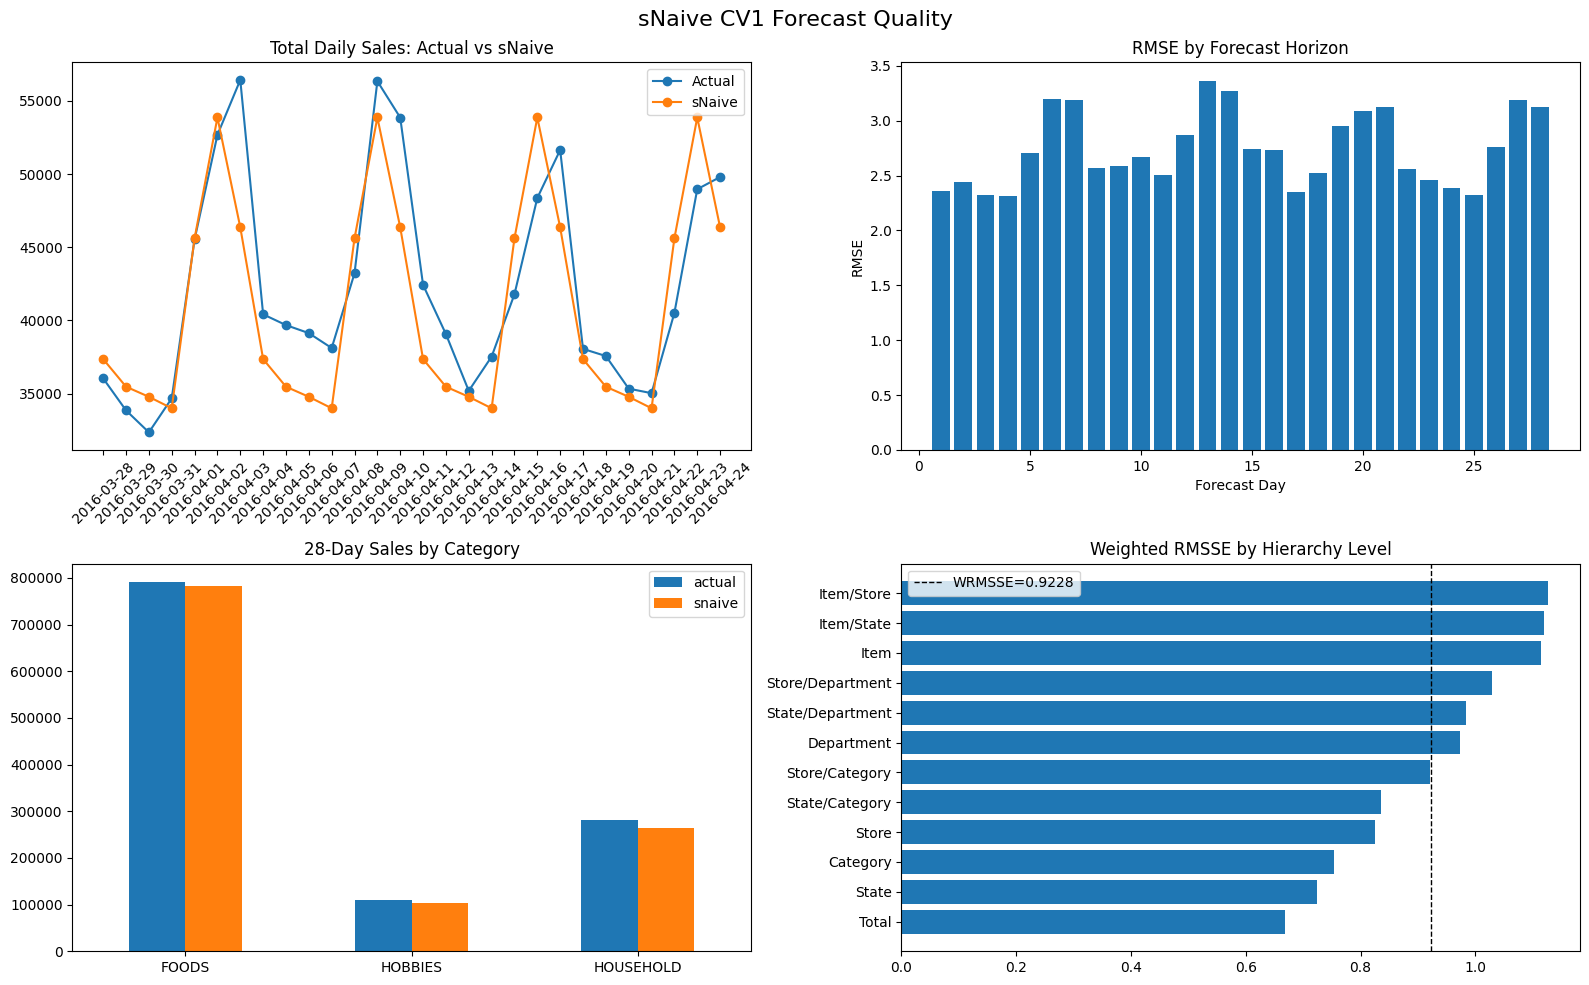

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("sNaive CV1 Forecast Quality", fontsize=16)

actual_total = cv1_actual.sum(axis=0)
pred_total = cv1_pred.sum(axis=0)
axes[0, 0].plot(cv1_dates, actual_total, marker="o", label="Actual")
axes[0, 0].plot(cv1_dates, pred_total, marker="o", label="sNaive")
axes[0, 0].set_title("Total Daily Sales: Actual vs sNaive")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].legend()

horizon_rmse = np.sqrt(((cv1_actual.to_numpy() - cv1_pred.to_numpy()) ** 2).mean(axis=0))
axes[0, 1].bar(range(1, HORIZON + 1), horizon_rmse)
axes[0, 1].set_title("RMSE by Forecast Horizon")
axes[0, 1].set_xlabel("Forecast Day")
axes[0, 1].set_ylabel("RMSE")

cat_compare = sales_train_validation[["cat_id"]].copy()
cat_compare["actual"] = cv1_actual.sum(axis=1).to_numpy()
cat_compare["snaive"] = cv1_pred.sum(axis=1).to_numpy()
cat_compare = cat_compare.groupby("cat_id", observed=True)[["actual", "snaive"]].sum()
cat_compare.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("28-Day Sales by Category")
axes[1, 0].set_xlabel("")
axes[1, 0].tick_params(axis="x", rotation=0)

level_plot = wrmsse_by_level.sort_values("weighted_rmsse", ascending=True)
axes[1, 1].barh(level_plot["level"], level_plot["weighted_rmsse"])
axes[1, 1].axvline(wrmsse_score, color="black", linestyle="--", linewidth=1, label=f"WRMSSE={wrmsse_score:.4f}")
axes[1, 1].set_title("Weighted RMSSE by Hierarchy Level")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

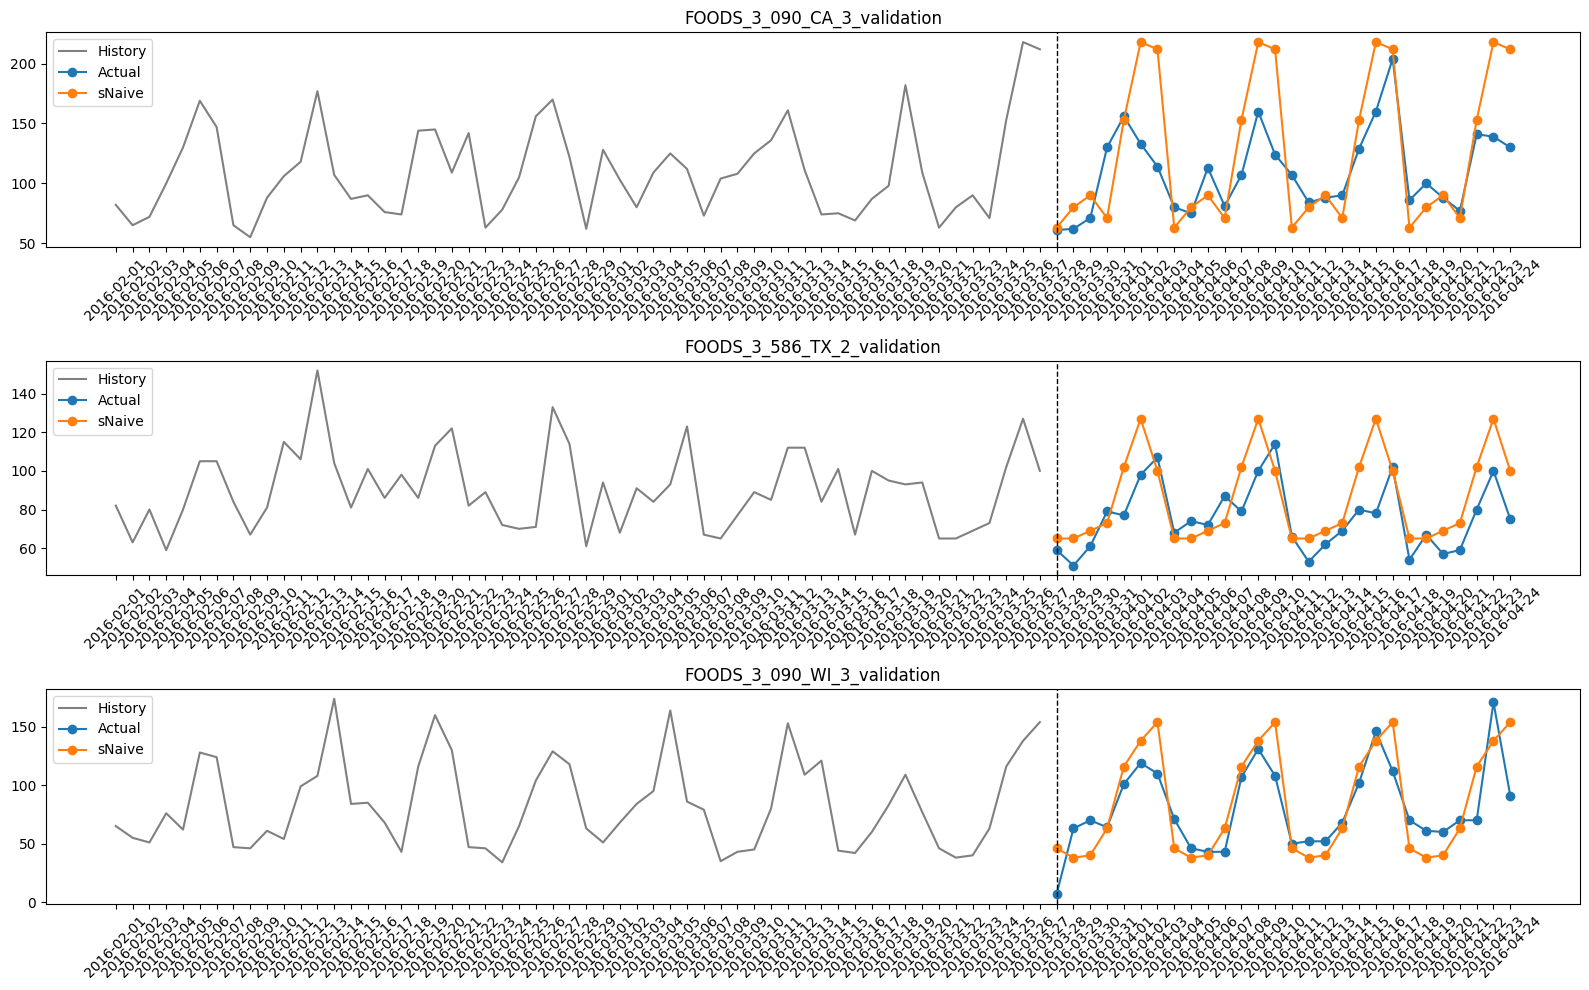

In [27]:
plot_history_days = [f"d_{d}" for d in range(CV1_TEST_START_DAY - 56, CV1_TEST_START_DAY)]
top_series_idx = sales_train_validation[plot_history_days].sum(axis=1).nlargest(3).index

fig, axes = plt.subplots(len(top_series_idx), 1, figsize=(16, 10), sharex=False)
if len(top_series_idx) == 1:
    axes = [axes]

history_dates = calendar.set_index("d").loc[plot_history_days, "date"]
for ax, idx in zip(axes, top_series_idx):
    row_id = sales_train_validation.loc[idx, "id"]
    ax.plot(history_dates, sales_train_validation.loc[idx, plot_history_days], label="History", color="gray")
    ax.plot(cv1_dates, sales_train_validation.loc[idx, test_days], marker="o", label="Actual")
    ax.plot(cv1_dates, snaive.loc[idx, test_days], marker="o", label="sNaive")
    ax.axvline(cv1_dates.iloc[0], color="black", linestyle="--", linewidth=1)
    ax.set_title(row_id)
    ax.tick_params(axis="x", rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()